In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path

import ssqueezepy as sq

path.append('../../wavelet/')
import wavelet_funcs as wf

In [2]:
n_signals = 100
nt = 512

x = np.random.randn(n_signals, nt)
dt = 0.5
fs = 1/dt
t = np.arange(nt)*dt

_freq_min_matlab = 0.0107
_freq_max_matlab = 0.7366

## Complex Morlet wavelet with default $\mu=13.4$ (Matches Generalized Morse Wavelets with (beta, gamma)=(3,60))

In [71]:
sq.Wavelet('morlet').config

{'mu': 13.4, 'dtype': 'float32'}

In [77]:
ps = []

for xi in x:
    
    Tx, Wx, freqs, scales = sq.ssq_cwt(xi, wavelet='morlet', fs=fs)
    
    ps.append(np.mean(abs(Wx**2), axis=1))
ps = np.array(ps)    

In [78]:
ps_mean = np.mean(ps, axis=0)

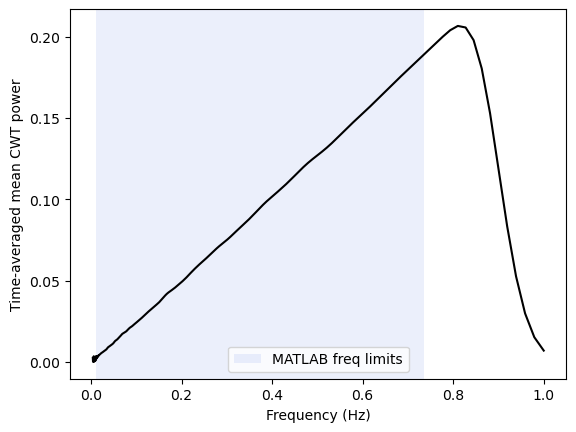

In [79]:
plt.plot(freqs, ps_mean, color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Time-averaged mean CWT power')
plt.axvspan(_freq_min_matlab, _freq_max_matlab, color='royalblue', alpha=0.1, label='MATLAB freq limits', lw=0)
plt.legend()

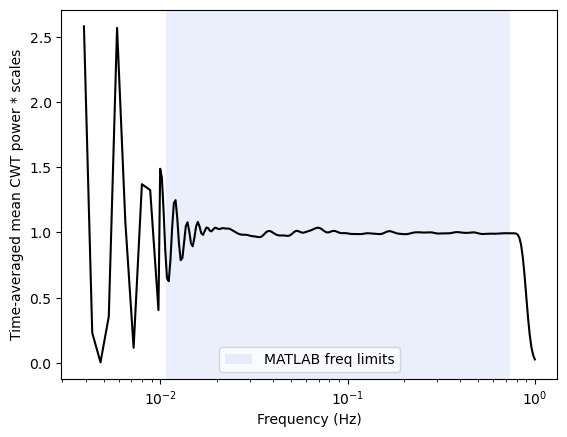

In [80]:
plt.semilogx(freqs, ps_mean*scales, color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Time-averaged mean CWT power * scales')
plt.axvspan(_freq_min_matlab, _freq_max_matlab, color='royalblue', alpha=0.1, label='MATLAB freq limits', lw=0)
plt.legend()

## $\mu=2$

In [60]:
wlt = sq.Wavelet(('morlet', {'mu':2}))

In [61]:
ps = []

for xi in x:
    
    Tx, Wx, freqs, scales = sq.ssq_cwt(xi, wlt, fs=fs)
    
    ps.append(np.mean(abs(Wx**2), axis=1))
ps = np.array(ps)    

In [62]:
ps_mean = np.mean(ps, axis=0)

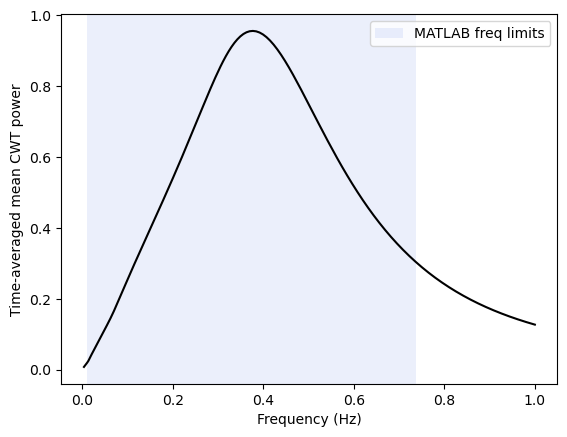

In [63]:
plt.plot(freqs, ps_mean, color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Time-averaged mean CWT power')
plt.axvspan(_freq_min_matlab, _freq_max_matlab, color='royalblue', alpha=0.1, label='MATLAB freq limits', lw=0)
plt.legend()

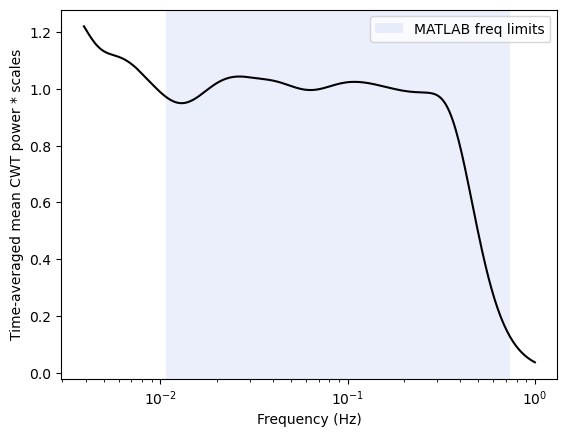

In [64]:
plt.semilogx(freqs, ps_mean*scales, color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Time-averaged mean CWT power * scales')
plt.axvspan(_freq_min_matlab, _freq_max_matlab, color='royalblue', alpha=0.1, label='MATLAB freq limits', lw=0)
plt.legend()

## $\mu=12$

In [65]:
wlt = sq.Wavelet(('morlet', {'mu':12}))

In [66]:
ps = []

for xi in x:
    
    Tx, Wx, freqs, scales = sq.ssq_cwt(xi, wlt, fs=fs)
    
    ps.append(np.mean(abs(Wx**2), axis=1))
ps = np.array(ps)    

In [67]:
ps_mean = np.mean(ps, axis=0)

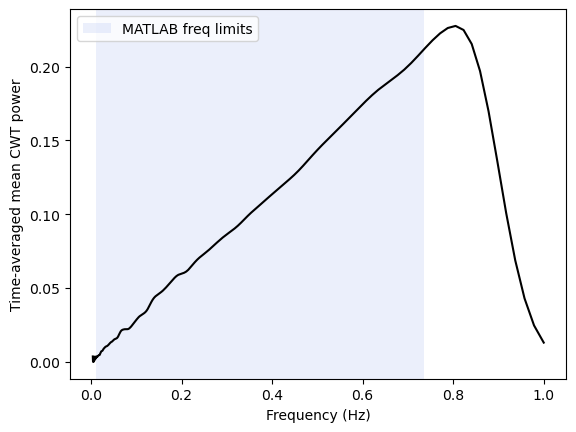

In [68]:
plt.plot(freqs, ps_mean, color='k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Time-averaged mean CWT power')
plt.axvspan(_freq_min_matlab, _freq_max_matlab, color='royalblue', alpha=0.1, label='MATLAB freq limits', lw=0)
plt.legend()

## Change normalization from L1 (default) to L2

In [6]:
sq.Wavelet('morlet').config

{'mu': 13.4, 'dtype': 'float32'}

In [24]:
ps = []

for xi in x:
    
    Wx, scales = sq.cwt(xi, wavelet='morlet', fs=fs, l1_norm=False)
    
    ps.append(np.mean(abs(Wx**2), axis=1))
ps = np.array(ps)    

In [25]:
ps_mean = np.mean(ps, axis=0)

Text(0, 0.5, 'Time-averaged mean CWT power')

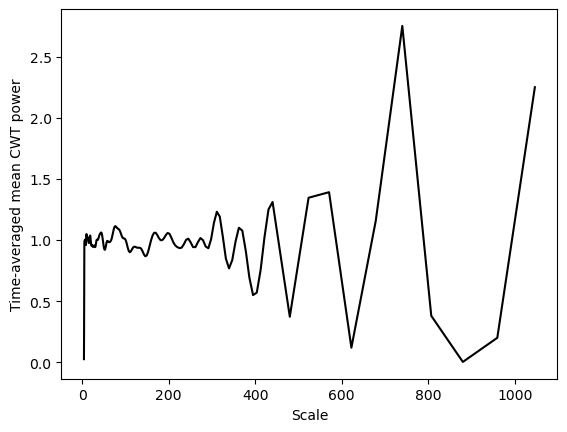

In [31]:
plt.plot(scales, ps_mean, color='k')
plt.xlabel('Scale')
plt.ylabel('Time-averaged mean CWT power')